In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Task 1: Generate 100 Random Numbers and Plot Bell Curve

Generate 100 random numbers following a normal distribution with mean = 50 and standard deviation = 10 using `numpy`, then plot the bell curve using `matplotlib`.

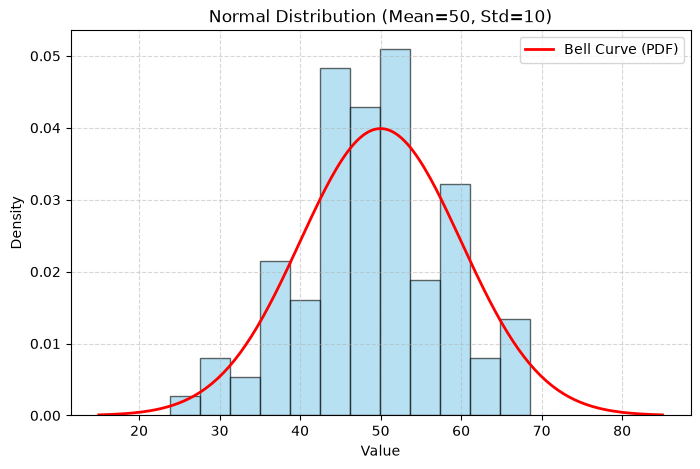

In [3]:
np.random.seed(42)

# Generate 100 random numbers from N(50, 10)
mean = 50
std_dev = 10
data = np.random.normal(loc=mean, scale=std_dev, size=100)

# Create a DataFrame
df_data = pd.DataFrame(data, columns=['Values'])

# Plot bell curve
plt.figure(figsize=(8, 5))
count, bins, ignored = plt.hist(df_data['Values'], bins=12, density=True, alpha=0.6, color='skyblue', edgecolor='black')

# Theoretical bell curve line
x = np.linspace(mean - 3.5 * std_dev, mean + 3.5 * std_dev, 200)
p = stats.norm.pdf(x, mean, std_dev)
plt.plot(x, p, 'r-', linewidth=2, label='Bell Curve (PDF)')

plt.title('Normal Distribution (Mean=50, Std=10)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Task 2: Mean, Median, and Mode for Daily Step Counts

Given an array of 20 daily step counts, calculate the mean, median, and mode, and check if they are approximately equal as expected in a normal distribution.

In [4]:
# Array of 20 daily step counts
step_counts = np.array([
    8200, 8100, 7950, 8000, 8050, 7900, 8150, 8000, 8300, 7850,
    8000, 8100, 7950, 8050, 8250, 8000, 8150, 7900, 8000, 8050
])

# Using pandas Series for clean inspection
steps_series = pd.Series(step_counts)

# Calculations using numpy and scipy
mean_steps = np.mean(step_counts)
median_steps = np.median(step_counts)
mode_steps = stats.mode(step_counts).mode

print(f"Mean:   {mean_steps:.2f}")
print(f"Median: {median_steps:.2f}")
print(f"Mode:   {mode_steps:.2f}")

# Check if approximately equal (within 1% relative tolerance)
is_approx_equal = np.isclose(mean_steps, median_steps, rtol=0.01) and np.isclose(median_steps, mode_steps, rtol=0.01)
print(f"\nAre Mean, Median, and Mode approximately equal? {'Yes' if is_approx_equal else 'No'}")

Mean:   8047.50
Median: 8025.00
Mode:   8000.00

Are Mean, Median, and Mode approximately equal? Yes


## Task 3: Simulate 200 Player Scores and Verify 68-95-99 Rule

Simulate scores of 200 players using a normal distribution with mean 70 and standard deviation 15, then count how many players scored within one standard deviation (between 55 and 85).

In [5]:
np.random.seed(42)

mean_score = 70
std_score = 15
num_players = 200

# Simulate scores
player_scores = np.random.normal(loc=mean_score, scale=std_score, size=num_players)
scores_df = pd.DataFrame(player_scores, columns=['Score'])

# 1 Standard deviation bounds
lower_limit = mean_score - std_score  # 55
upper_limit = mean_score + std_score  # 85

# Count players within one standard deviation
within_one_std = scores_df['Score'].between(lower_limit, upper_limit)
count_within_std = np.sum(within_one_std)
percentage = (count_within_std / num_players) * 100

print(f"Total Players: {num_players}")
print(f"Players scoring between {lower_limit} and {upper_limit}: {count_within_std}")
print(f"Calculated Percentage: {percentage:.2f}%")
print(f"Expected by 68-95-99 Rule: ~68.27%")

Total Players: 200
Players scoring between 55 and 85: 145
Calculated Percentage: 72.50%
Expected by 68-95-99 Rule: ~68.27%


## Task 4: Real-World Scenario Explanation

**Scenario: Delivery Times for Zomato Orders**

Delivery times fit a normal distribution because most orders arrive near a consistent central average (e.g., 30 minutes) under standard kitchen prep and road conditions. Minor everyday variations—such as individual traffic signals, kitchen queues, or elevator wait times—act as multiple independent variables that sum together to balance out around the mean. Extreme delays (over an hour) or exceptionally fast runs (under 10 minutes) occur rarely, resulting in a symmetric bell curve shape centered at the mean delivery time.